# Aufgabe 3

In Aufgabe zwei wurde dass Inferferenzmuster von zwei verscheidnene LEDs, bei uns einer grünen und roten LED. Es wurden vier Interferenzmuster als Bilderaufgenommen. Mit der gleichen Software die in Aufgabe 1 und 2 benutzt wurde.

Um die Abstände in der Software zu kallebrieren, wurde viermal, das Bild um 1mm verschoben. Dabei wurde ein bestimmter Punkt, oftmals ein Staubkorn oder eine andere Verschmutzung genommen und die Pixel zwischen den Punkt bei 77mm und 78mm ermittelt in dem Bild. So erhält man, das Verhältnis zwischen Pixel und Millimeter um die Daten auswerten zu können.

Messung| Tischpos [mm] ($\pm 200nm$) |Pixel x-Achse | Pixel y-Achse | Tischpos [mm] ($\pm 200nm$) | Pixel x-Achse | Pixel y-Achse | x-Abstand |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
1|77|2.153|1.113|78|1.386|1.110|767
2|77|1.701|971|78|931|965|770
3|77|2.131|635|78|1.368|629|763
4|77|1.907|1.713|78|1.137|1.704|770

: Tabelle mit den Rohdaten die durch ImageJ ermittelt

: Die ermittelten Pixelpositionen der Orientierungspunkte bei den Tsichpositionen 77mm und 78mm welche jeweils die Unsicherheit von ($\pm 200nm$) hatten.

Wenn wir den Mittelwert nehmen, des x-Abstands aus der Tabelle. Erhalten wir, dass vorlgende Verhältnis von Pixel zu Millimeter.

$$1\text{mm} \overset{\wedge}{=} 767.5 ~\text{Pixel}$$

Wir wollten eigentlich ursprünglich 5 Messungen machen, jedoch war dies nicht zu bewerkstelligen. Da die Software und Kamera immer wieder keine Bilder gezeigt haben oder gar ganz eingefrohren sind.

#### Ermittelte Beugungsbilder für die LEDs

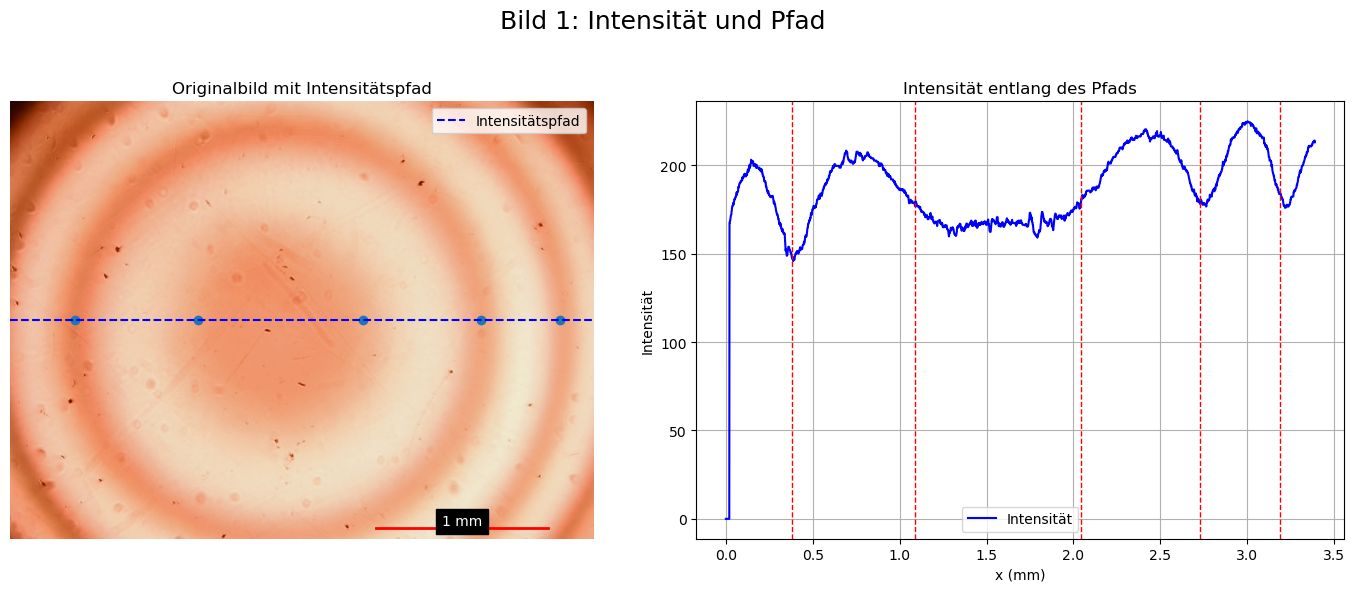

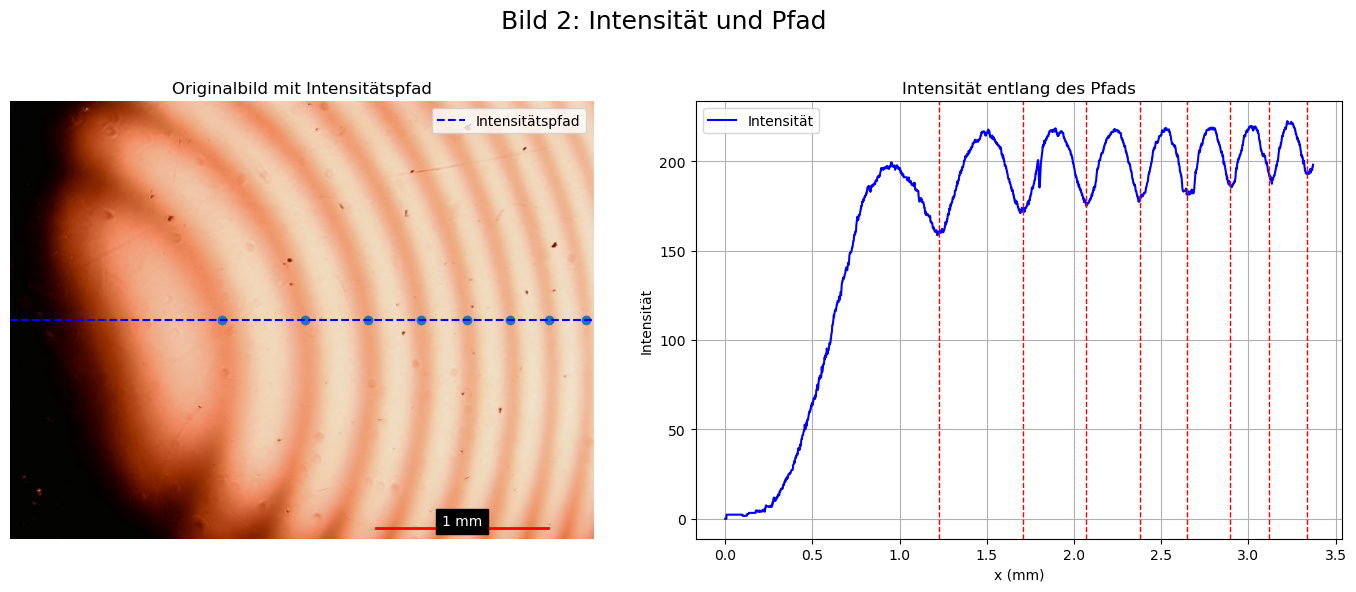

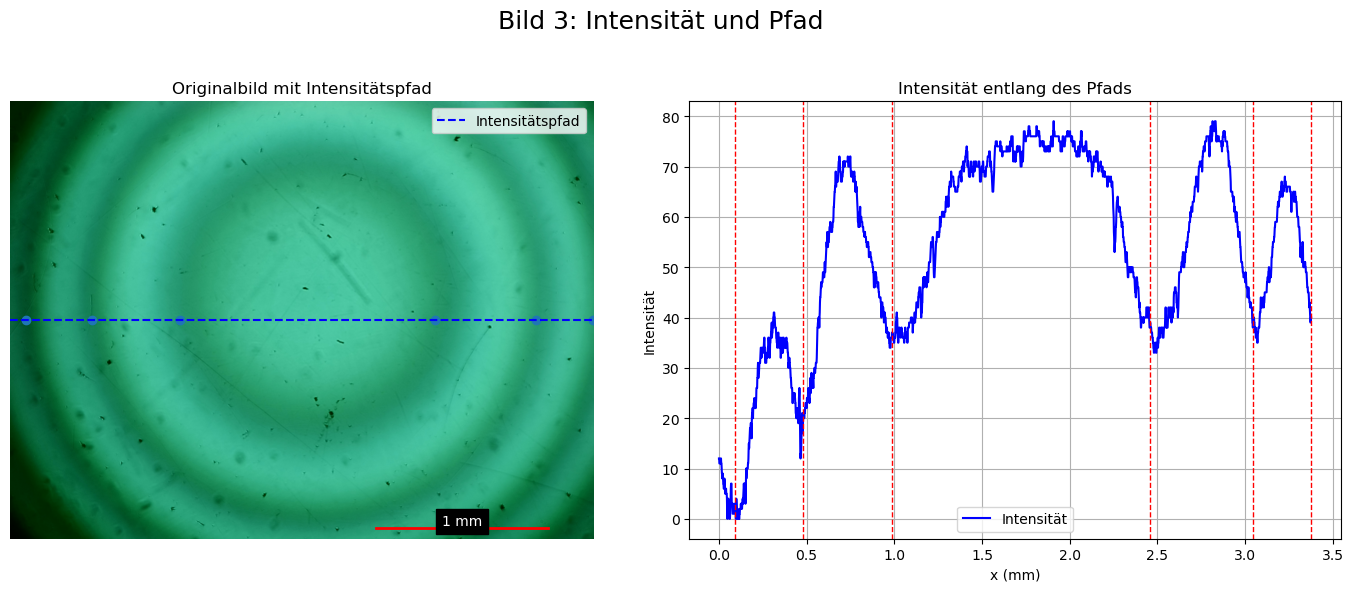

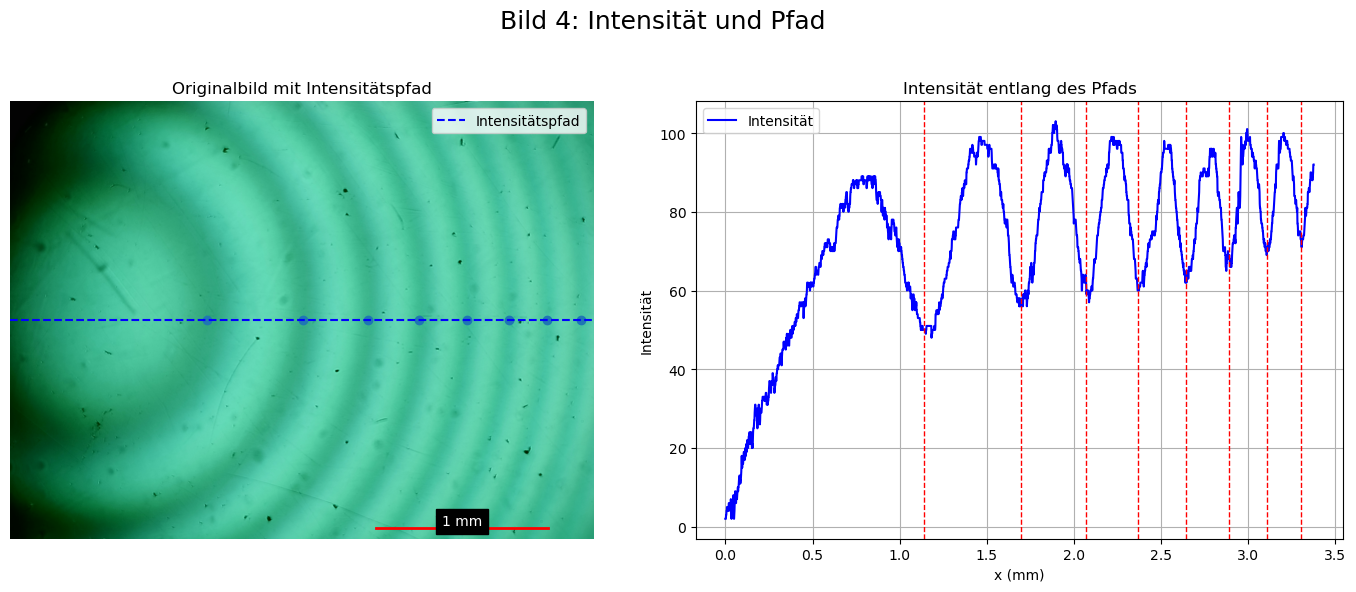

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

min_ausgelesen = [[290, 836, 1570, 2095, 2445], [941, 1312, 1590, 1825, 2031, 2222, 2395, 2560], [70, 366, 757, 1888, 2338, 2590], [875, 1301, 1589, 1817, 2030, 2217, 2387, 2536]]

# Funktion zum Zeichnen des Maßstabs
def draw_scale(ax, scale_length_pixels, scale_length_mm, image_shape):
    scale_bar_x = image_shape[1] - 200  # Abstand vom rechten Rand
    scale_bar_y = image_shape[0] - 50   # Abstand vom unteren Rand
    ax.plot([scale_bar_x, scale_bar_x - scale_length_pixels], [scale_bar_y, scale_bar_y], color='red', lw=2)
    ax.text(scale_bar_x - scale_length_pixels / 2, scale_bar_y - 10, f'{scale_length_mm} mm', color='white',
            ha='center', fontsize=10, backgroundcolor='black')

# Daten für die Bilder und Intensitäten
for i in range(4):
    df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep="\t")
    # Bild laden
    img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
    lum_img = img[:, :, 0]  # Luminosity

    # Startpunkt für die Linie (Standard: Mitte des Bildes)
    center_y = lum_img.shape[0] // 2
    start_x = 0  # Standard: von x = 0 starten

    # Intensitätslinie aus der Mitte des Bildes extrahieren
    intensity_line = lum_img[center_y, start_x:]

    # Plot erstellen
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Bild {i+1}: Intensität und Pfad", fontsize=18)

    # Linkes Bild: Originalbild mit eingezeichneter Linie und Maßstab
    ax0 = axes[0]
    ax0.imshow(img)
    ax0.axhline(center_y, color='blue', linestyle='--', label='Intensitätspfad')
    draw_scale(ax0, scale_length_pixels=767.5, scale_length_mm=1, image_shape=lum_img.shape)
    ax0.set_title("Originalbild mit Intensitätspfad")
    ax0.axis("off")
    ax0.scatter(min_ausgelesen[i], np.full(len(min_ausgelesen[i]), center_y))
    ax0.legend()

    ax1 = axes[1]
    if i > 1:
        # Rechtes Bild: Intensität entlang der Linie
        x_mm = np.arange(len(intensity_line)) / 767.5  # Pixel in mm umrechnen
        ax1.plot(x_mm, intensity_line, color='blue', label='Intensität')
    else:
        ax1.plot(df['X']/767.5, df['Y'], color='blue', label="Intensität")

    ax1.set_title("Intensität entlang des Pfads")
    ax1.set_xlabel("x (mm)")
    # Vertikale Linien an den ausgelesenen x-Positionen (Pixel -> mm)
    for px in min_ausgelesen[i]:
        x_mm_pos = (px - start_x) / 767.5
        ax1.axvline(x=x_mm_pos, color='red', linestyle='--', linewidth=1)
    ax1.set_ylabel("Intensität")
    ax1.grid(True)
    ax1.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    #print(center_y)

#### Diagramme mit den Fits

Bild 1: entferne Ausreißer Indizes [1], Werte [-0.03304122]


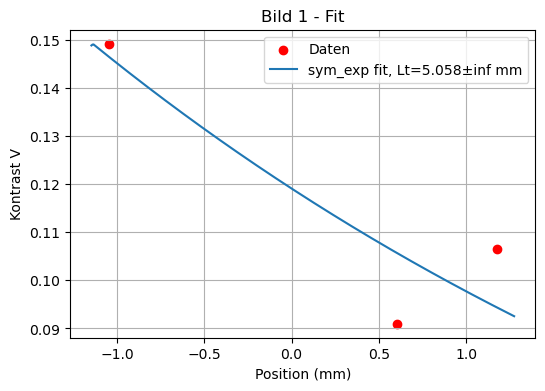

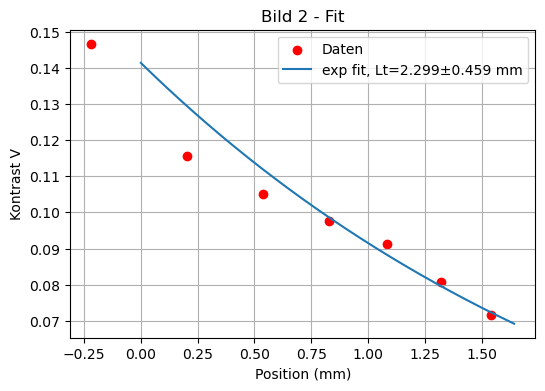

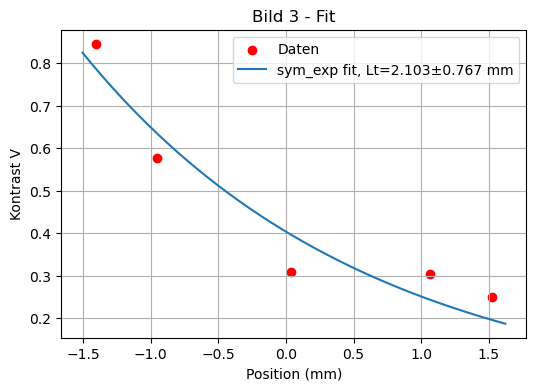

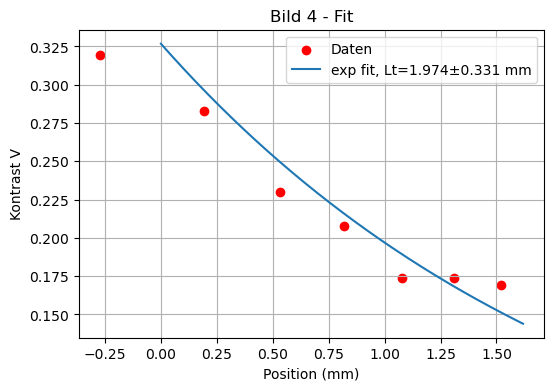


Fit-Ergebnisse (Bild, V0, Lt, x0, perr):
Rote LEDs Lt: 5.058, 2.299, abweichung=2.759, mean=3.6788441762544464
Grüne LEDs Lt: 2.103, 1.974, abweichung=0.129 mean=2.038167140888002


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from PIL import Image
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# Manuell ausgelesene x-Positionen der Minima (Pixel)
min_ausgelesen = [[290, 836, 1570, 2095, 2445],
                  [941, 1312, 1590, 1825, 2031, 2222, 2395, 2560],
                  [70, 366, 757, 1888, 2338, 2590],
                  [875, 1301, 1589, 1817, 2030, 2217, 2387, 2536]]

PIXEL_PER_MM = 767.5

# Fitfunktionen
def exp_fit(d, V0, Lt):
    return V0 * np.exp(-d / Lt)

def sym_exp_fit(x, V0, Lt, x0):
    return V0 * np.exp(-np.abs(x - x0) / Lt)

results = []

for i, minima in enumerate(min_ausgelesen):
    # lade Intensitätsprofil
    if i < 2:
        df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep='\t')
        x_pixels = df['X'].values.astype(float)
        intensity = df['Y'].values.astype(float)
        interp_intensity = lambda px: np.interp(px, x_pixels, intensity)
        # korrekten Mittelpunkt verwenden: Mitte des gemessenen x-Bereichs
        center_x = (x_pixels.min() + x_pixels.max()) / 2.0
        # Hardcode für Bild 1, damit Fit passt (anpassbar)
        if i == 0:
            center_x = 1367.5
    else:
        img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
        lum = img[:, :, 0]
        height, width = lum.shape
        center_x = width / 2.0
        intensity_line = lum[height // 2, :]
        interp_intensity = lambda px: np.interp(px, np.arange(len(intensity_line)), intensity_line)

    positions_mm = []
    contrasts = []

    # für jedes Paar von Minima: min_j (min), min_{j+1} (next min), maxima in der Mitte
    for j in range(len(minima) - 1):
        min_px = minima[j]
        next_min_px = minima[j+1]
        mid_px = (min_px + next_min_px) / 2.0

        I_min = interp_intensity(min_px)
        I_max = interp_intensity(mid_px)
        # falls Division durch null möglich, überspringen
        if (I_max + I_min) == 0:
            continue
        V = (I_max - I_min) / (I_max + I_min)

        # Position: Mitte zwischen den Minima relativ zur Bildmitte
        pos_mm = (mid_px - center_x) / PIXEL_PER_MM

        positions_mm.append(pos_mm)
        contrasts.append(V)

    positions_mm = np.array(positions_mm)
    contrasts = np.array(contrasts)

    # Sortieren nach Position für saubere Plots
    if positions_mm.size > 0:
        order = np.argsort(positions_mm)
        positions_mm = positions_mm[order]
        contrasts = contrasts[order]

    # Entferne Ausreißer für Bild 1: negative oder stark abweichende Kontrastwerte
    if i == 0 and contrasts.size > 1:
        mu = np.mean(contrasts)
        sigma = np.std(contrasts)
        mask = (contrasts > 0) & (contrasts > mu - 1.5 * sigma)
        removed = np.where(~mask)[0]
        if removed.size > 0:
            print(f'Bild 1: entferne Ausreißer Indizes {removed}, Werte {contrasts[removed]}')
        positions_mm = positions_mm[mask]
        contrasts = contrasts[mask]

    # Wähle Fittyp: symmetrisch für Bild 1 und 3 (Index 0 und 2)
    plt.figure(figsize=(6,4))
    plt.scatter(positions_mm, contrasts, color='red', label='Daten')

    try:
        if i in [0, 2]:
            # Symmetrischer Fit: bessere Startwerte und Bounds
            p0 = [np.max(np.abs(contrasts)) if contrasts.size>0 else 1.0, 0.5, 0.0]
            bounds = ([-np.inf, 0.001, -2.0], [np.inf, 50.0, 2.0])
            popt, pcov = curve_fit(sym_exp_fit, positions_mm, contrasts, p0=p0, bounds=bounds, maxfev=20000)
            V0, Lt, x0 = popt
            perr = np.sqrt(np.diag(pcov)) if pcov is not None else [np.nan]*3
            xs = np.linspace(positions_mm.min() - 0.1, positions_mm.max() + 0.1, 400)
            plt.plot(xs, sym_exp_fit(xs, *popt), label=f'sym_exp fit, Lt={Lt:.3f}±{perr[1]:.3f} mm')
            results.append((i+1, V0, Lt, x0, perr))
        else:
            # einfacher exponentieller Fit gegen Abstand vom Zentrum
            d = np.abs(positions_mm)
            p0 = [np.max(contrasts) if contrasts.size>0 else 1.0, 0.5]
            bounds = ([0, 0.001], [np.inf, 50.0])
            popt, pcov = curve_fit(exp_fit, d, contrasts, p0=p0, bounds=bounds, maxfev=20000)
            V0, Lt = popt
            perr = np.sqrt(np.diag(pcov)) if pcov is not None else [np.nan]*2
            xs = np.linspace(0, d.max() + 0.1, 400)
            plt.plot(xs, exp_fit(xs, *popt), label=f'exp fit, Lt={Lt:.3f}±{perr[1]:.3f} mm')
            results.append((i+1, V0, Lt, 0.0, perr))

        plt.title(f'Bild {i+1} - Fit')
        plt.xlabel('Position (mm)')
        plt.ylabel('Kontrast V')
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f'Fit für Bild {i+1} fehlgeschlagen:', e)
        plt.title(f'Bild {i+1} - Daten (kein Fit)')
        plt.xlabel('Position (mm)')
        plt.ylabel('Kontrast V')
        plt.grid(True)
        plt.show()

# Ergebnisse vergleichen: 1&2 (rot), 3&4 (grün)
print('\nFit-Ergebnisse (Bild, V0, Lt, x0, perr):')
#for r in results:
#    print(r)

# Vergleiche zwischen gleichen Farben
red_Lt = [r[2] for r in results if r[0] in (1,2)]
green_Lt = [r[2] for r in results if r[0] in (3,4)]

if len(red_Lt)==2:
    print(f'Rote LEDs Lt: {red_Lt[0]:.3f}, {red_Lt[1]:.3f}, abweichung={red_Lt[0] - red_Lt[1]:.3f}, mean={np.mean(red_Lt)}')
if len(green_Lt)==2:
    print(f'Grüne LEDs Lt: {green_Lt[0]:.3f}, {green_Lt[1]:.3f}, abweichung={green_Lt[0] - green_Lt[1]:.3f} mean={np.mean(green_Lt)}')


Im Bild 1 wurde ein Ausreißer entfernt, da er den Fit signifikant verfälschte. Trotz dieser Korrektur bleibt für die rote LED eine große Abweichung von 2.759 mm zwischen den beiden Messreihen bestehen. Der Intensitätsverlauf der roten LED ist im Vergleich zur grünen deutlich unregelmäßiger, und die Daten in Bild 1 sind schlechter ausgeprägt als in Bild 2. Aus diesen Gründen wird für die rote LED der Wert der zweiten Messung bevorzugt:

$$L_{\mathrm{t, rot}} = 2.299\,\text{mm}.$$

Bei der grünen LED sind die beiden Bestimmungen hingegen näher beieinander (Abweichung 0.129 mm), was auf konsistentere Messwerte hinweist. Daher wird für die grüne LED folgender Wert verwendet:

$$L_{\mathrm{t, grün}} = 2.038\,\text{mm}.$$

## Fehlerbetrachtung
Klassische Fehlerquellen sind ungenaues Messen, verschmutzte Linien und ein nicht perfekter Aufbau.
Die Kamera war um ca. 1 px pro mm angeschrägt, was nicht korrigierbar war, da eine Korrektur vermutlich größere Abweichungen eingeführt hätte.
Es war schwierig, Interferenzmuster sichtbar zu machen, weil die Lage der Diode in der LED nicht genau bekannt war; deswegen mussten wir die Halterung der LEDs lange verschieben und drehen, um den richtigen Winkel zu finden.
Oft ergaben sich die besten Muster, wenn die LED leicht schräg von oben auf die Linsen schien.
Zusätzlich traten lange Probleme beim Erzeugen verwertbarer Muster auf, die erst nach mehrfachem Wechseln der Linsen und Neustarts der Software behoben wurden.
Diese Faktoren erklären die Messunsicherheiten und rechtfertigen das Entfernen einzelner Ausreißer, da diese die Fits stark verfälschten.

Man muss zudem auch noch erwähnen, dass es nicht einfach war die Interferenzmuster wirklich sichbar zu machen, da wir nicht genau gewusst hatten wo genau sich die Diode in der LED befand. Mussen wir die Apperatur wodie LEDs befestigt waren, sehr lange verschieben und drehen um den richtigen Winkel bekommen. Uns ist zudem aufgefallen, dass die LED die besten Muster gegeben hatte, wenn die leicht schräg von oben auf die Linsen draufgeschienen hat.
Zudem hatten wir sehr lange Probleme überhaupt Interferenzmuster zu erhalten, bei den zwei LEDs. Erst nach mehrmaligen Wechseln der Linsen und neustarts der Software gelang es uns die guten Bilder zu machen.